In [1]:
PROJECT_DIR = './'
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import *
from darts import TimeSeries
from darts.dataprocessing.transformers import (
    WindowTransformer, StaticCovariatesTransformer, Scaler,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

In [2]:
# -------------------- CONFIG --------------------
DATA_FOLDER       = "./data"
FIXED_DATA_PATH   = construct_path(DATA_FOLDER, "fixed")
DATASET_PATH      = construct_path(DATA_FOLDER, "dataset")
EDA_DATA_PATH = construct_path(DATA_FOLDER, "for_eda")
EDA_PLOT_DATA_PATH = construct_path(EDA_DATA_PATH, "plots")

TARGET            = "act_drone_strike_on_ua"

OUTPUT_CHUNK_LEN  = 7
INPUT_LAGS        = 7
MULTI_MODELS      = True

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20

In [3]:
import geopandas as gpd
ukr_admin = gpd.read_file(construct_path(EDA_DATA_PATH,"./Ukraine_Admin_Regions.geojson"))
ukr_admin = ukr_admin.to_crs(epsg=32635)

In [ ]:
# Rewired onto the `strikecast` package (plan §8 P7).
#
# `build_panel_legacy_regressor` reproduces `src.get_engineered_features`
# EXACTLY -- that equality is asserted on the real data, column by column and
# dtype by dtype, by tests/golden/test_panel_equality.py (golden level A). The
# names below are kept so every downstream cell of this notebook is unchanged.
from strikecast.data import build_panel_legacy_regressor, load_inputs

inputs = load_inputs(FIXED_DATA_PATH, DATASET_PATH)
regions, master_timeseries, regions_activity = (
    inputs.regions,
    inputs.master,
    inputs.activity_by_region,
)

_panel = build_panel_legacy_regressor(inputs, target_col=TARGET)
for_global_reset, global_weather_columns = _panel.panel, _panel.global_weather_columns


In [5]:
variables = for_global_reset.columns.to_list()
print(f"Total amount of features: {len(variables)}\n")

d = {}
no_type = []

for feature in variables:
    if "_" in feature:
        prefix = feature.split("_")[0]
        
        if prefix not in d:
            d[prefix] = []
        d[prefix].append(feature)
    else:
        no_type.append(feature)

for prefix, features_list in d.items():
    print(f"Type '{prefix}'")
    print(f"amount of features: {len(features_list)}")
    print("features: ", features_list, '\n')

print("Features that do not belong to any type:")
for feature in no_type:
    print(f"- {feature}")

Total amount of features: 116

Type 'event'
amount of features: 1
features:  ['event_date'] 

Type 'acled'
amount of features: 6
features:  ['acled_other_rus_armed_clash', 'acled_other_rus_disrupted_weapons_use', 'acled_other_rus_shelling_artillery_missile_attack', 'acled_other_ua_armed_clash', 'acled_other_ua_disrupted_weapons_use', 'acled_other_ua_shelling_artillery_missile_attack'] 

Type 'act'
amount of features: 27
features:  ['act_drone_infra_ua_education_intent', 'act_drone_infra_ua_education_unintent', 'act_drone_infra_ua_energy_intent', 'act_drone_infra_ua_energy_unintent', 'act_drone_infra_ua_health_intent', 'act_drone_infra_ua_health_unintent', 'act_drone_infra_ua_residential_intent', 'act_drone_infra_ua_residential_unintent', 'act_drone_strike_on_rus_in_ua_nofpv', 'act_drone_strike_on_ua', 'act_confirmed_launched', 'act_confirmed_destroyed', 'act_intercept_rate', 'act_cyber_rus_ua', 'act_cyber_rus_nato', 'act_cyber_rus_other', 'act_cyber_ua_rus', 'act_cyber_ua_other', 'act_

In [6]:
regions_activity

{'crimea': 0,
 'zakarpattia': 0,
 'volyn': 0,
 'chernivtsi': 0,
 'ternopil': 0,
 'zhytomyr': 1,
 'cherkasy': 1,
 'poltava': 1,
 'lviv': 1,
 'khmelnytskyi': 1,
 'kirovohrad': 1,
 'ivano-frankivsk': 1,
 'luhansk': 1,
 'vinnytsia': 1,
 'rivne': 1,
 'kyiv': 2,
 'mykolaiv': 2,
 'odesa': 2,
 'donetsk': 2,
 'chernihiv': 3,
 'sumy': 3,
 'kharkiv': 3,
 'kherson': 3,
 'zaporizhia': 3,
 'dnipropetrovsk': 3}

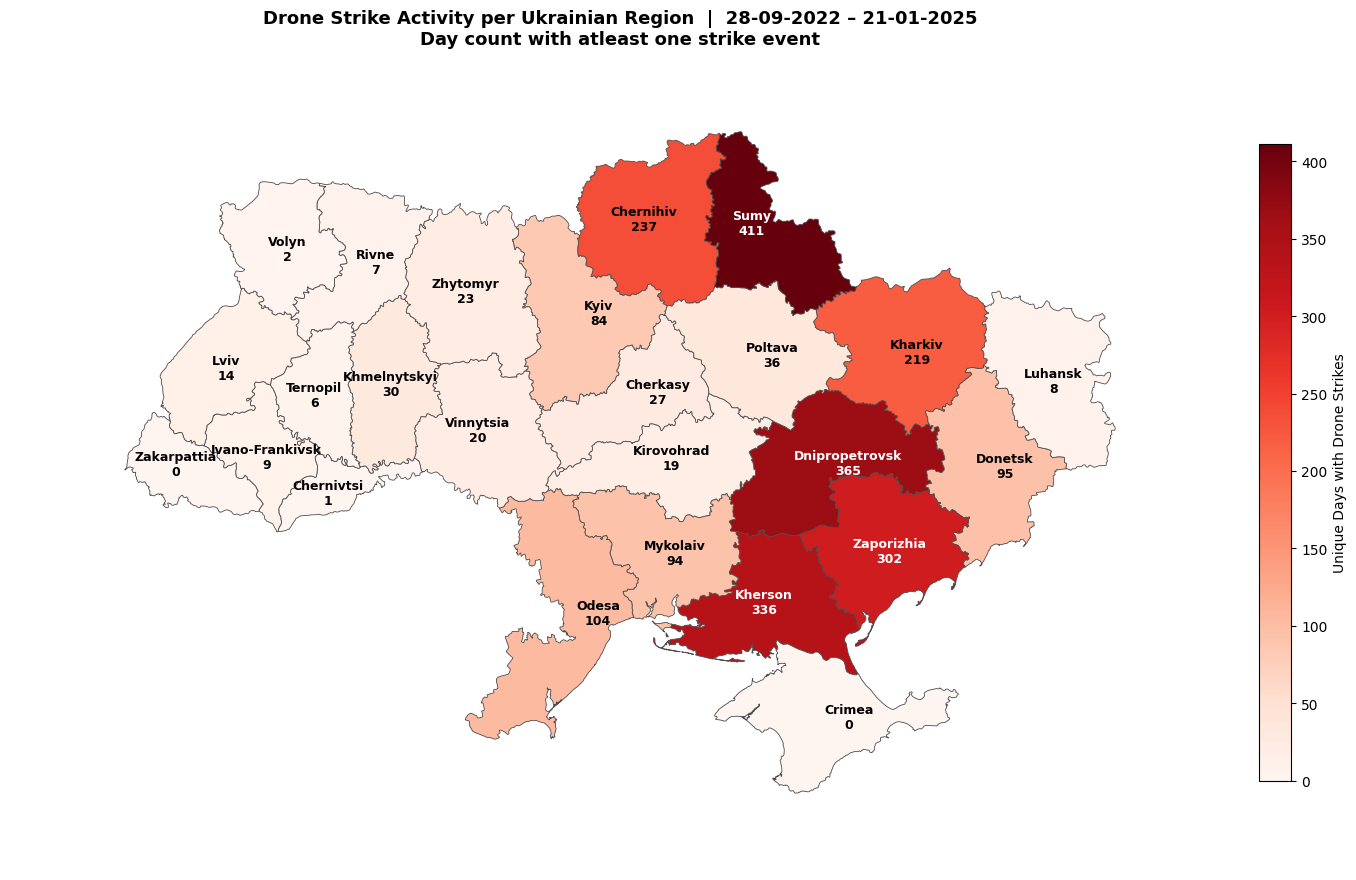

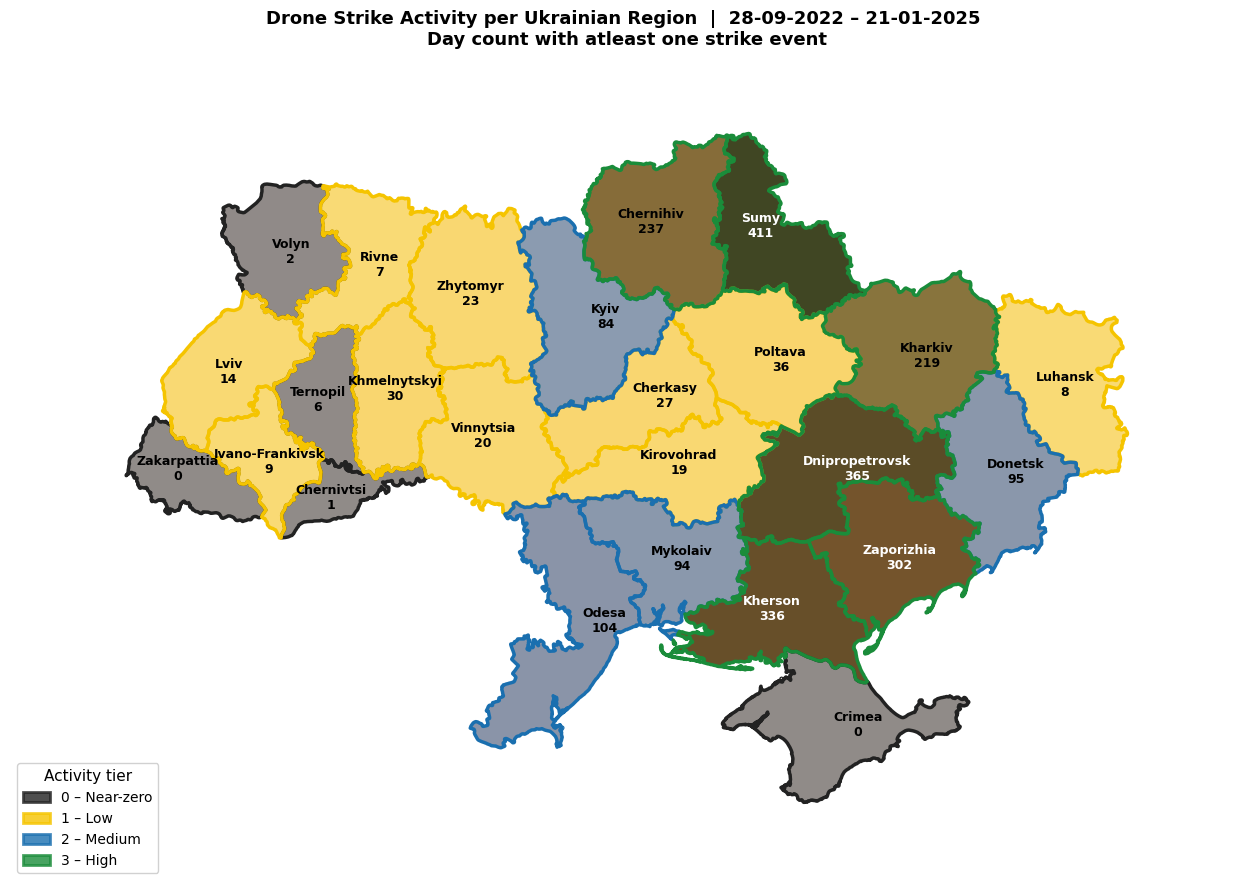

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

strike_totals = []
base_target = 'act_drone_strike_on_ua'

for region in regions:
    col_name = f"{base_target}_{region}"
    if col_name in master_timeseries.columns:
        active_days = (master_timeseries[col_name] > 0).sum()
        strike_totals.append({'region_lower': region, 'Active_Days': active_days})

active_days_strikes_df = pd.DataFrame(strike_totals)

ukr_admin['region_lower'] = ukr_admin['ADM1_NAME'].str.lower()
map_data = ukr_admin.merge(active_days_strikes_df, on='region_lower', how='left')
map_data['Active_Days'] = map_data['Active_Days'].fillna(0)

activity_df = pd.DataFrame(list(regions_activity.items()), columns=['region_lower', 'activity_level'])
map_data = map_data.merge(activity_df, on='region_lower', how='left')
map_data['activity_level'] = map_data['activity_level'].fillna(0).astype(int)

EDGE_COLORS  = {0: '#222222', 1: '#f5c400', 2: '#1a6faf', 3: '#1a8c3a'}
LEVEL_LABELS = {0: 'Near-zero', 1: 'Low', 2: 'Medium', 3: 'High'}
OVERLAY_ALPHA = 0.50

max_days = map_data['Active_Days'].max()

def add_labels(ax, fontsize=9):
    for _, row in map_data.iterrows():
        pt    = row.geometry.representative_point().coords[0]
        v     = row['Active_Days']
        color = "white" if v >= max_days * 0.6 else "black"
        ax.text(*pt, f"{row['ADM1_NAME']}\n{v:,.0f}",
                ha='center', va='center', fontsize=fontsize,
                fontweight='bold', color=color, clip_on=False)

def add_margins(ax, pct=0.06):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    xpad = (xmax - xmin) * pct
    ypad = (ymax - ymin) * pct
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

# ── Plot 1: Heatmap ───────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(15, 9))
ax1.set_title("Drone Strike Activity per Ukrainian Region  |  28-09-2022 – 21-01-2025\nDay count with atleast one strike event",
              fontsize=13, fontweight='bold', pad=8)

map_data.plot(column='Active_Days', cmap='Reds', linewidth=0.6,
              ax=ax1, edgecolor='0.3', legend=True,
              legend_kwds={'label': 'Unique Days with Drone Strikes',
                           'orientation': 'vertical', 'shrink': 0.75, 'pad': 0.02})
add_labels(ax1)
add_margins(ax1)
ax1.axis('off')
plt.tight_layout()
plt.savefig(construct_path(EDA_PLOT_DATA_PATH,"strike_activity_per_region.svg"))
plt.show()

# ── Plot 2: Activity tier overlay ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(15, 9))
ax2.set_title("Drone Strike Activity per Ukrainian Region  |  28-09-2022 – 21-01-2025 \nDay count with atleast one strike event",
              fontsize=13, fontweight='bold', pad=8)

map_data.plot(column='Active_Days', cmap='Reds', linewidth=0,
              ax=ax2, edgecolor='none', legend=False)

for level, color in EDGE_COLORS.items():
    subset = map_data[map_data['activity_level'] == level]
    subset.plot(ax=ax2, facecolor=color, alpha=OVERLAY_ALPHA, edgecolor='none', linewidth=0)
    subset.plot(ax=ax2, facecolor='none', edgecolor=color, linewidth=2.5)

add_labels(ax2)
add_margins(ax2)
ax2.axis('off')

legend_patches = [
    mpatches.Patch(facecolor=EDGE_COLORS[i], alpha=OVERLAY_ALPHA + 0.3,
                   edgecolor=EDGE_COLORS[i], linewidth=2,
                   label=f"{i} – {LEVEL_LABELS[i]}")
    for i in range(4)
]
ax2.legend(handles=legend_patches, title="Activity tier",
           loc='lower left', fontsize=10, title_fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(construct_path(EDA_PLOT_DATA_PATH,"strike_activity_per_region_activity_level.svg"))
plt.show()



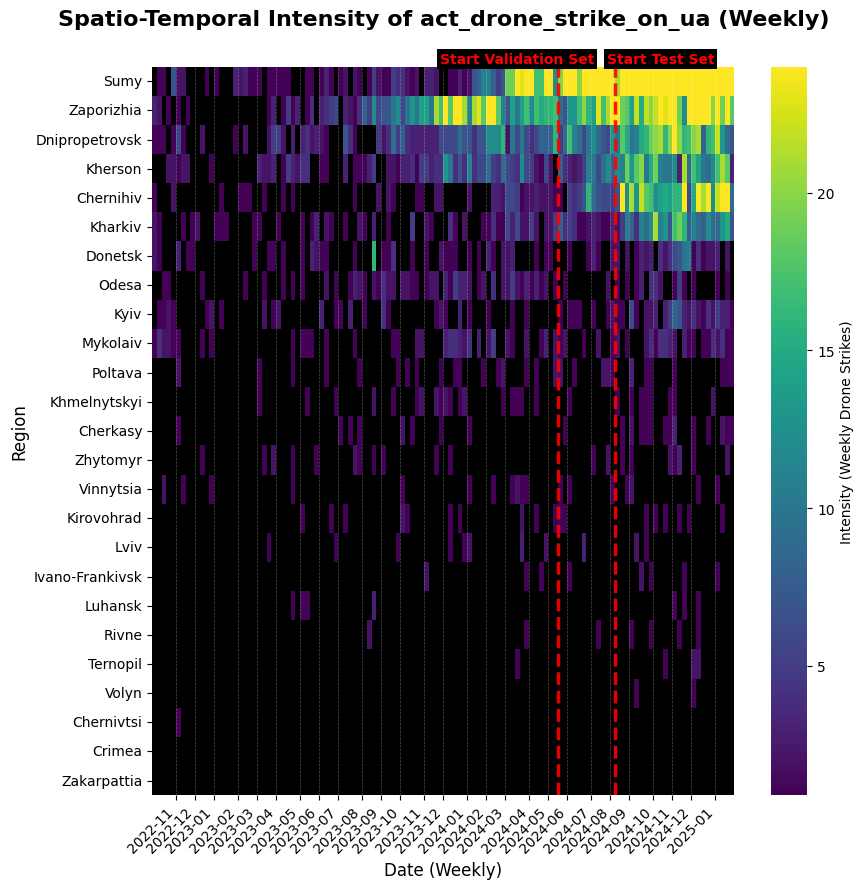

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_base = 'act_drone_strike_on_ua'
strike_cols = [f"{target_base}_{region}" for region in regions if f"{target_base}_{region}" in master_timeseries.columns]

df_heat = master_timeseries[['event_date'] + strike_cols].copy()
df_heat['event_date'] = pd.to_datetime(df_heat['event_date'])
df_heat = df_heat.sort_values('event_date').set_index('event_date')

# Clean up column names
df_heat.columns = [col.replace(f"{target_base}_", "").title() for col in df_heat.columns]

df_heat = df_heat.resample('W').sum()

# Fill any missing weeks with 0 and transpose so Dates are X and Regions are Y
df_heat_t = df_heat.fillna(0).T

# --- SORTING LOGIC ---
region_totals = df_heat_t.sum(axis=1)
df_heat_t = df_heat_t.loc[region_totals.sort_values(ascending=False).index]
# -------------------------

# Set up the plot
fig, ax = plt.subplots(figsize=(9, 9))

# Create the heatmap
cmap = plt.cm.viridis.copy()
cmap.set_under("#000000")   # any neutral colour you like for "no events"

sns.heatmap(
    df_heat_t,
    cmap=cmap,
    vmin=0.9,               # 0 < 0.5, so it hits set_under
    robust=True,
    cbar_kws={'label': 'Intensity (Weekly Drone Strikes)'},
    ax=ax,
    linewidths=0,
    linecolor=None
)


dates = df_heat_t.columns
n_cols = len(dates)

# Month lines — now more subtle
month_starts = [i for i in range(1, n_cols) if dates[i].month != dates[i-1].month]
for idx in month_starts:
    ax.axvline(x=idx, color='white', linestyle='--', linewidth=0.5, alpha=0.3)

ax.set_xticks(month_starts)
ax.set_xticklabels([dates[i].strftime('%Y-%m') for i in month_starts], rotation=45, ha='right')

# Set-split lines at 70% and 80%
val_split = int(n_cols * 0.70)
test_split = int(n_cols * 0.80)
n_rows = len(df_heat_t)

for x_pos, label, y_frac,x_offset in [
    (val_split,  'Start Validation Set', -0.02,25),
    (test_split, 'Start Test Set',       -0.02,2),
]:
    ax.axvline(x=x_pos, color='red', linestyle='--', linewidth=2.5, alpha=0.9)
    ax.text(
        x_pos-x_offset + 0.3, n_rows * y_frac,
        label,
        color='red', fontsize=10, fontweight='bold',
        va='top', ha='left',
        bbox=dict(facecolor='black', edgecolor='none', alpha=1, pad=2)
    )


ax.set_xlabel("Date (Weekly)", fontsize=12)
ax.set_ylabel("Region", fontsize=12)
plt.title(f"Spatio-Temporal Intensity of {target_base} (Weekly)", fontsize=16, fontweight='bold', pad=30)

plt.tight_layout()

plt.savefig(construct_path(EDA_PLOT_DATA_PATH,"spatiotemporalintensityheatmap.svg"))
plt.show()


In [67]:
# ── 0. Shared imports & helpers for the EDA ───────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from itertools import combinations
from scipy import stats
from statsmodels.tsa.stattools  import acf, pacf, adfuller, kpss, ccf
from statsmodels.tsa.seasonal   import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.discrete.count_model import (
    ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP
)
from statsmodels.discrete.discrete_model import Poisson, NegativeBinomial
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import AgglomerativeClustering

TARGET_BASE = "act_drone_strike_on_ua"
ACTIVE_REGIONS = [r for r in regions if regions_activity.get(r, 0) != 0]   # 20 oblasts
TARGET_COLS    = [f"{TARGET_BASE}_{r}" for r in ACTIVE_REGIONS
                  if f"{TARGET_BASE}_{r}" in master_timeseries.columns]
TIERS          = sorted({regions_activity[r] for r in ACTIVE_REGIONS})     # [1, 2, 3]

# Chronological split indices (70 / 10 / 20), identical to the modelling pipeline.
N_DAYS         = len(master_timeseries)
IDX_TRAIN_END  = int(np.floor(N_DAYS * 0.70))
IDX_VAL_END    = int(np.floor(N_DAYS * 0.80))
DATE_TRAIN_END = master_timeseries.index[IDX_TRAIN_END - 1]
DATE_VAL_END   = master_timeseries.index[IDX_VAL_END   - 1]

def tier_pool(df_wide, tier, cols=TARGET_COLS):
    """Return a 1-D ndarray of pooled region-day observations for one tier."""
    cols_t = [c for c in cols
              if regions_activity[c.replace(f"{TARGET_BASE}_", "")] == tier]
    return df_wide[cols_t].to_numpy().ravel()

def region_panel(df_wide, cols=TARGET_COLS):
    """Return ndarray of shape (T, R) of raw counts ordered by ACTIVE_REGIONS."""
    return df_wide[cols].to_numpy()

# Convenience: national daily total (all 20 modelled regions, raw counts).
NAT_TOTAL = master_timeseries[TARGET_COLS].sum(axis=1).rename("national_total")

TIER_COLOR  = {1: "#f5c400", 2: "#1a6faf", 3: "#1a8c3a"}
TIER_LABEL  = {1: "Tier 1 (Low)", 2: "Tier 2 (Medium)", 3: "Tier 3 (High)"}

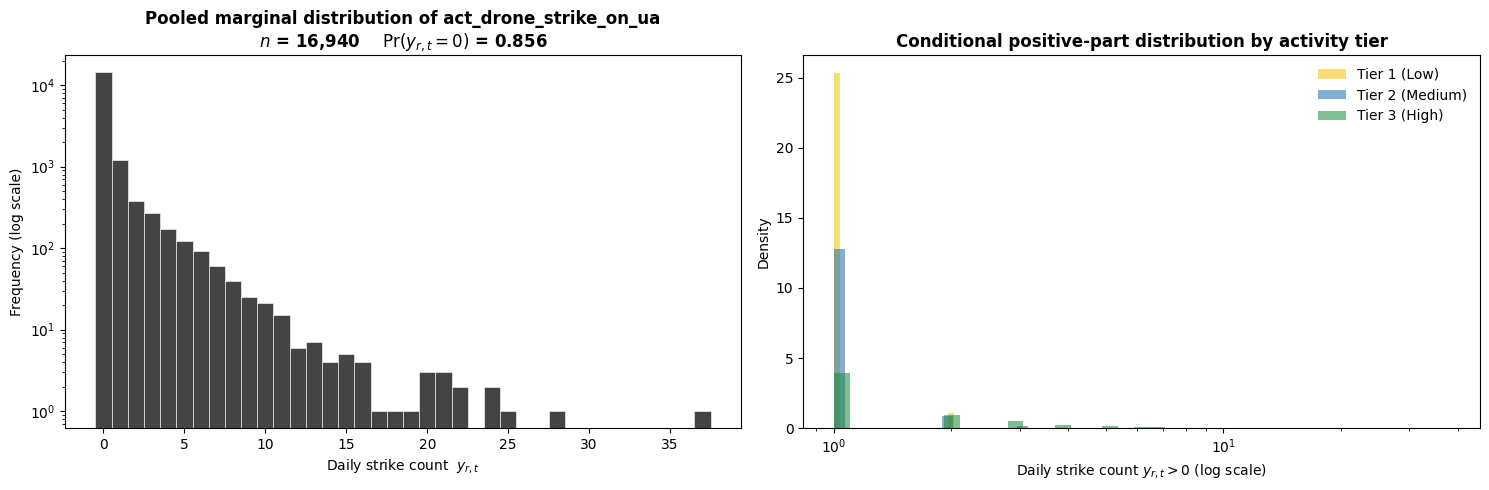

In [68]:
# ── Plot 3: Pooled marginal distribution of the raw count target ──────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: overall pooled distribution, log-frequency y-axis.
pooled = master_timeseries[TARGET_COLS].to_numpy().ravel()
zero_rate = (pooled == 0).mean()

axes[0].hist(pooled, bins=np.arange(0, pooled.max() + 2) - 0.5,
             color="#444", edgecolor="white", linewidth=0.4)
axes[0].set_yscale("log")
axes[0].set_xlabel(f"Daily strike count  $y_{{r,t}}$")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_title(f"Pooled marginal distribution of {TARGET_BASE}\n"
                  f"$n$ = {pooled.size:,}    "
                  fr"$\Pr(y_{{r,t}}=0)$ = {zero_rate:.3f}",
                  fontsize=12, fontweight="bold")

# Right panel: tier-conditional densities of the *positive* part, log x-axis.
for t in TIERS:
    vals = tier_pool(master_timeseries, t)
    pos  = vals[vals > 0]
    axes[1].hist(pos, bins=np.logspace(0, np.log10(pos.max() + 1), 40),
                 alpha=0.55, color=TIER_COLOR[t], label=TIER_LABEL[t],
                 density=True)
axes[1].set_xscale("log")
axes[1].set_xlabel(r"Daily strike count $y_{r,t}>0$ (log scale)")
axes[1].set_ylabel("Density")
axes[1].set_title("Conditional positive-part distribution by activity tier",
                  fontsize=12, fontweight="bold")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(construct_path(EDA_PLOT_DATA_PATH, "target_marginal_distribution.svg"))
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

infra_types = ['health', 'education', 'residential', 'energy']
base_col    = 'act_drone_infra_ua'
intention   = 'intent'

for infra in infra_types:
    target_base = f"{base_col}_{infra}_{intention}"
    infra_cols  = [f"{target_base}_{r}" for r in regions if f"{target_base}_{r}" in master_timeseries.columns]

    df_heat = master_timeseries[['event_date'] + infra_cols].copy()
    df_heat['event_date'] = pd.to_datetime(df_heat['event_date'])
    df_heat = df_heat.sort_values('event_date').set_index('event_date')
    df_heat.columns = [col.replace(f"{target_base}_", "").title() for col in df_heat.columns]

    df_heat   = df_heat.resample('W').sum()
    df_heat_t = df_heat.fillna(0).T

    region_totals = df_heat_t.sum(axis=1)
    df_heat_t = df_heat_t.loc[region_totals.sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(16, 10))

    sns.heatmap(
        df_heat_t,
        cmap="viridis",
        cbar_kws={'label': f'Intensity (Weekly {infra.capitalize()} Damage Events)'},
        robust=True,
        ax=ax,
        linewidths=0
    )

    dates  = df_heat_t.columns
    n_cols = len(dates)
    n_rows = len(df_heat_t)

    month_starts = [i for i in range(1, n_cols) if dates[i].month != dates[i - 1].month]
    for idx in month_starts:
        ax.axvline(x=idx, color='white', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_xticks(month_starts)
    ax.set_xticklabels([dates[i].strftime('%Y-%m') for i in month_starts], rotation=45, ha='right')

    val_split  = int(n_cols * 0.70)
    test_split = int(n_cols * 0.80)

    for x_pos, label, x_offset in [
        (val_split,  'Start Validation Set', 10),
        (test_split, 'Start Test Set',        2),
    ]:
        ax.axvline(x=x_pos, color='red', linestyle='--', linewidth=2.5, alpha=0.9)
        ax.text(
            x_pos - x_offset + 0.3, n_rows * -0.02,
            label,
            color='red', fontsize=10, fontweight='bold',
            va='top', ha='left',
            bbox=dict(facecolor='black', edgecolor='none', alpha=0.5, pad=2)
        )

    ax.set_xlabel("Date (Weekly)", fontsize=12)
    ax.set_ylabel("Region", fontsize=12)
    plt.title(
        f"Spatio-Temporal Intensity of {infra.capitalize()} Infrastructure Damage (Weekly)",
        fontsize=16, fontweight='bold', pad=30
    )

    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

infra_types = ['health', 'education', 'residential', 'energy']

base_col    = 'act_drone_infra_ua'
intention   = 'intent'

ukr_admin['region_lower'] = ukr_admin['ADM1_NAME'].str.lower()

def _add_labels(ax, map_data, max_days, fontsize=9):
    for _, row in map_data.iterrows():
        pt    = row.geometry.representative_point().coords[0]
        v     = row['Active_Days']
        color = "white" if (max_days > 0 and v >= max_days * 0.6) else "black"
        ax.text(*pt, f"{row['ADM1_NAME']}\n{v:,.0f}",
                ha='center', va='center', fontsize=fontsize,
                fontweight='bold', color=color, clip_on=False)

def _add_margins(ax, pct=0.06):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    xpad = (xmax - xmin) * pct
    ypad = (ymax - ymin) * pct
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

for infra in infra_types:
    totals = []
    for region in regions:
        col = f"{base_col}_{infra}_{intention}_{region}"
        if col in master_timeseries.columns:
            active_days = (master_timeseries[col] > 0).sum()
            totals.append({'region_lower': region, 'Active_Days': int(active_days)})

    infra_df = pd.DataFrame(totals)
    map_data = ukr_admin.merge(infra_df, on='region_lower', how='left')
    map_data['Active_Days'] = map_data['Active_Days'].fillna(0)
    max_days = map_data['Active_Days'].max()

    fig, ax = plt.subplots(figsize=(15, 9))
    ax.set_title(
        f"Infrastructure Damage – {infra.capitalize()}  |  28-09-2022 – 21-01-2025",
        fontsize=13, fontweight='bold', pad=8
    )

    map_data.plot(column='Active_Days', cmap='Reds', linewidth=0.6,
                  ax=ax, edgecolor='0.3', legend=True,
                  legend_kwds={'label': 'Days with Damage Events',
                               'orientation': 'vertical', 'shrink': 0.75, 'pad': 0.02})
    _add_labels(ax, map_data, max_days)
    _add_margins(ax)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
